<a href="https://colab.research.google.com/github/nadiia2302/etl-book-sales-analytics/blob/main/All_datas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import yaml
import numpy as np
import matplotlib.pyplot as plt

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
def process_data(path, title_name):
  users = pd.read_csv(path + '/users.csv')
  users_copy = users.copy()
  users['phone'] = users['phone'].str.replace("(","").str.replace(")","").str.replace(".","").str.replace(" ","").str.replace("-","").str.replace(",","")
  users['email'] = users['email'].str.lower()
  users['phone'] = pd.to_numeric(users['phone'])
  garbage_values = ["NULL", "null", "None", "none", "", " ","NaN","\t"]
  users['address']= users['address'].replace(garbage_values, np.nan)
  users['address']= users['address'].fillna('unknown')
  users.drop_duplicates(keep = "first").shape
  users = users.drop_duplicates(subset=['phone','email','name'])
  users = users.drop_duplicates(subset=['phone','address','name'])
  users = users.drop_duplicates(subset=['email','address','name'])
  users = users.drop_duplicates(subset=['phone','email','address'])
  # print(f"Users size in {title_name} is {users.shape}")
  # print(f"Users in {title_name}")
  # display(users)
  with open(path + '/books.yaml') as file:
    books_list = yaml.safe_load(file)
  books = pd.DataFrame(books_list)
  books[':year'] = pd.to_numeric(books[':year'], errors='coerce')
  books[':year'] = books[':year'].fillna(0).astype('int64')
  garbage_values = ["NULL", "null", "None", "none", "", " ","NaN","\t"]

  books[':publisher'] = books[':publisher'].replace(garbage_values, np.nan)
  books[':publisher'] = books[':publisher'].fillna("unknown")
  books.drop_duplicates(keep = False).shape
  books = books.drop_duplicates(subset=[':author',':title',':genre'])
  # print(f"Books size in {title_name} is {books.shape}")
  # print(f"Books in {title_name}")
  # display(books)
  orders = pd.read_parquet(path + '/orders.parquet')
  orders['unit_price'] = orders['unit_price'].str.replace("¢",".")
  unit_price = orders.unit_price.tolist()
  clean_prices = []
  currencies = []
  for up in unit_price:
    if "USD" in up or "$" in up:
      clean_unit_price = up.replace("$","").replace("USD","")
      currency = "$"
    elif "EUR" in up or "€" in up:
      clean_unit_price = up.replace("€","").replace("EUR","")
      currency = "€"
    else:
      currency = "$"
    clean_prices.append(clean_unit_price)
    currencies.append(currency)
  orders['unit_price'] = clean_prices
  orders['currency'] = currencies
  orders['unit_price'] = orders['unit_price'].str.rstrip('.')
  orders['unit_price'] = pd.to_numeric(orders['unit_price'])
  orders['timestamp'] = orders['timestamp'].str.replace(";"," ").str.replace(","," ")
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
  garbage_values = ["NULL", "null", "None", "none", "", " ","NaN"]
  orders['shipping'] = orders['shipping'].replace(garbage_values, np.nan)
  orders['shipping'] = orders['shipping'].fillna("unknown")
  orders.drop_duplicates(keep = "first").shape
  orders = orders.drop_duplicates(subset=['user_id','book_id','quantity','timestamp'])
  orders = orders.drop_duplicates(subset=['user_id','book_id','timestamp'])
  orders = orders.copy()
  orders['paid_price'] = orders['quantity'] * orders['unit_price']
  orders.loc[orders.currency == "€", 'paid_price'] = orders['quantity'] * orders['unit_price']*1.2
  orders['date'] = orders['timestamp'].dt.date
  # print(f"Orders size in {title_name} is {orders.shape}")
  # print(f"Orders in {title_name}")
  # display(orders)
  daily_revenue = orders.groupby('date')['paid_price'].sum()
  top_5_days = daily_revenue.nlargest(5)
  print("Top 5 days by revenue:\n", top_5_days,"\n")
  print("The real amount of unique users: ", len(users),"\n")
  merged_books_orders = pd.merge(orders, books, left_on = 'book_id', right_on = ':id', how = 'right' )
  merged_books_orders
  # the most popular sold books by books
  split_author_by_delimeter = merged_books_orders[':author'].str.split(",")
  clean_authors = split_author_by_delimeter.apply(lambda x: sorted([i.strip() for i in x]))
  clean_authors = clean_authors.fillna("")
  merged_books_orders[':author'] = clean_authors.str.join(", ")
  popular_authors = merged_books_orders.groupby([':author'])['quantity'].sum()
  unique_authors = len(merged_books_orders[':author'].unique())
  print("The unique sets of authors are:", unique_authors,"\n")
  print("The name of most popular author (or author sets)\n")
  print(popular_authors.nlargest(n=5),"\n")
  merged_users_orders = pd.merge(orders, users, left_on = "user_id", right_on = "id", how = "inner")
  top_customers = merged_users_orders.groupby(['email','phone','name','address'])['paid_price'].sum()
  best_email = top_customers.nlargest(1).index[0][0]
  best_customer = users_copy[users_copy['email'] == best_email]['id'].unique().tolist()
  print(f"Best buyer is {best_email} with aliases as an array of ids {best_customer}\n")
  daily_revenue.plot( kind = "line")
  plt.title('Daily revenue chart')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.figure(figsize=(10, 5))
  users.to_csv('users_final_'+title_name+'.csv', index=False)
  orders.to_csv('orders_final_'+title_name+'.csv', index=False)
  books.to_csv('books_final_'+title_name+'.csv', index=False)

In [25]:
path1 = '/content/drive/MyDrive/Data_Engineering/data/DATA1'
path2 = '/content/drive/MyDrive/Data_Engineering/data/DATA2'
path3 = '/content/drive/MyDrive/Data_Engineering/data/DATA3'
title_name1 = "data1"
title_name2 = "data2"
title_name3 = "data3"

/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "10/01/24 10:38:08 A.M." included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "08:48:47 A.M. 28-August-2024" included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognize

Top 5 days by revenue:
 date
2024-12-17    57011.458
2024-11-03    46656.298
2025-03-23    39120.974
2024-09-06    33490.168
2025-01-25    31732.458
Name: paid_price, dtype: float64 

The real amount of unique users:  3125 

The unique sets of authors are: 325 

The name of most popular author (or author sets)

:author
Cathy Kovacek PhD                     133
Arlinda Huel                          128
Crysta Armstrong, Salvador D'Amore    124
Ms. Numbers Kris                      122
Maynard Bartoletti Ret.               120
Name: quantity, dtype: int32 

Best buyer is jon@lindgren.example with aliases as an array of ids [45800]



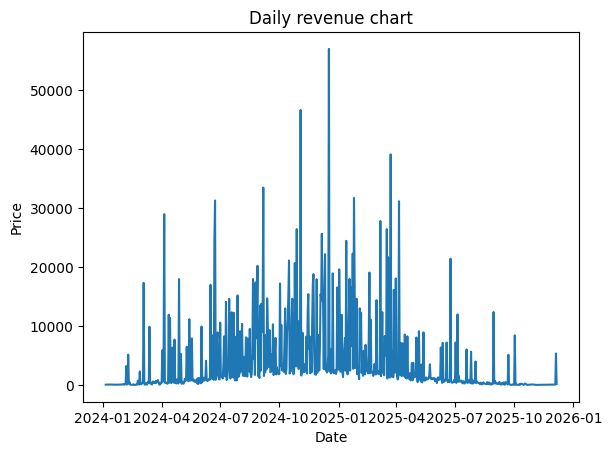

<Figure size 1000x500 with 0 Axes>

In [26]:
result1 = process_data(path1, title_name1)

/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "08:47:31 P.M. 10/07/24" included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "2025-01-06 07:14:37 P.M." included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized ti

Top 5 days by revenue:
 date
2024-12-24    42137.010
2024-08-29    40556.078
2024-12-29    39297.212
2025-01-30    39021.688
2024-11-29    35207.050
Name: paid_price, dtype: float64 

The real amount of unique users:  2671 

The unique sets of authors are: 293 

The name of most popular author (or author sets)

:author
Jaimie Skiles                                                            146
Adrian Stroman PhD, Hilario Legros I, Marco Cormier, Morton Goodwin I    143
Brianna O'Conner                                                         136
Aron Hansen                                                              120
Harold Blanda, Karan Abernathy, Mariella Zboncak DVM, Tifany Dickens     117
Name: quantity, dtype: int32 

Best buyer is chuck@crooks.test with aliases as an array of ids [53256]



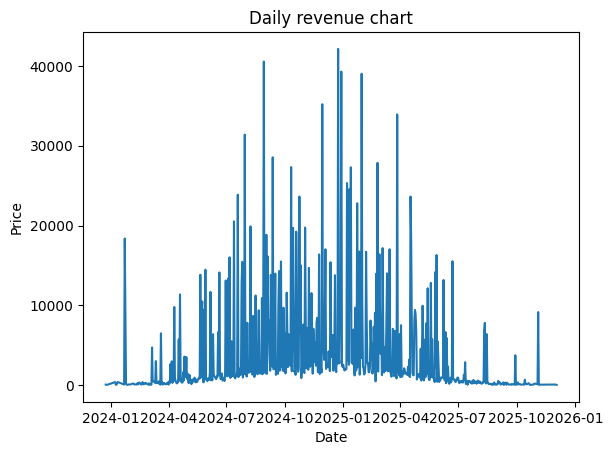

<Figure size 1000x500 with 0 Axes>

In [27]:
result2 = process_data(path2, title_name2)


/tmp/ipykernel_839/537434575.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "04/16/25 08:36:11 A.M." included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  orders['timestamp']=pd.to_datetime(orders['timestamp'],errors='coerce')
/tmp/ipykernel_839/537434575.py:53: FutureWarning: Parsed string "03:29:22 P.M.  10-Apr-2025" included an un-recognized timezone "M". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized 

Top 5 days by revenue:
 date
2025-02-03    64015.690
2024-07-26    38903.900
2024-11-03    32869.500
2024-09-06    31896.228
2024-09-20    30660.500
Name: paid_price, dtype: float64 

The real amount of unique users:  3301 

The unique sets of authors are: 268 

The name of most popular author (or author sets)

:author
Coy Streich, Keeley Hand, Lela Emard    125
Benjamin Mills                          116
Johnny Russel                           116
Prof. Remedios Powlowski                114
Karisa Kozey                            111
Name: quantity, dtype: int32 

Best buyer is shella_cronin@harber.example with aliases as an array of ids [50286]



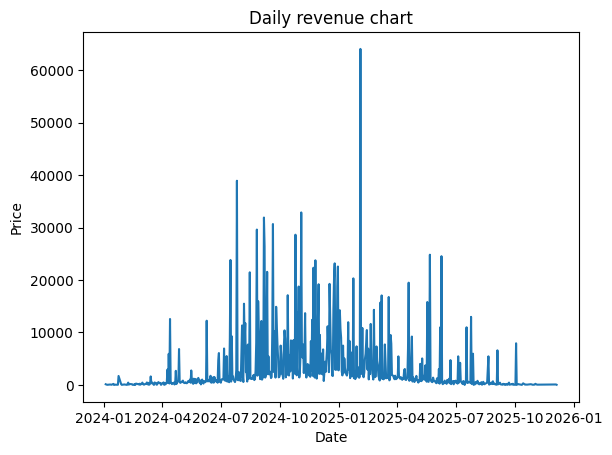

<Figure size 1000x500 with 0 Axes>

In [28]:
result3 = process_data(path3, title_name3)